# Project: Analyzing Sneaker Sale Data 

### Project Goal

This project aims to answer: **Do Off-White and Yeezy sneakers differ significantly 
in their resale market performance?** Specifically, we will compare retail prices, 
sale prices, and markup percentages to determine which brand commands higher premiums 
in the resale market.

### How to work with the notebook
1. Run the cells from top to bottom, as some later sections depend on variables and outputs created earlier in the notebook.
2. The required libraries, such as pandas, matplotlib, seaborn, and Google's genai package, are imported in the code as you run it. Make sure all dependencies are installed beforehand, especially if you want to run later sections of the notebook.
3. The raw dataset is located at `data/Sneaker_Data.csv` in the GitHub project folder. To run the notebook correctly, the full project folder should be downloaded so that Python can access the file from the `data/` folder. Alternatively, the same folder structure can be recreated locally.
4. The notebook includes data loading, cleaning, transformation, visual analysis, quantitative analysis, and result exports.
5. The final results are exported as CSV files for easier review, and charts are also saved as image files.

### Notebook Code Structure and Data Pipeline

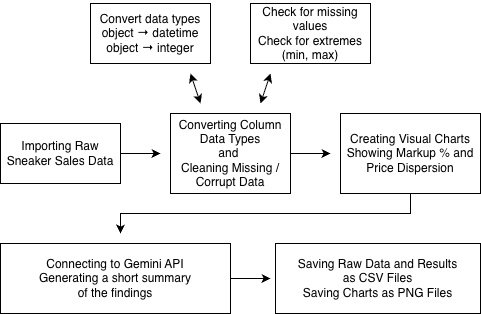


### Introduction

The secondary sneaker market has exploded over the past decade, with special edition releases often selling multiple times that of their original retail prices at stores. This project analyzes transaction data from StockX to answer two questions: 
1. Which brands and models deliver the highest return on investment (ROI) for resellers?
2. How do resale price and retail price distributions differ between brands in terms of spread, concentration, and typical price level?

The dataset uses thousands of authenticated sneaker transactions. 

In [51]:
# Importing dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats

In [52]:
# Loading and exporting the raw data file

from pathlib import Path

Path("exports").mkdir(exist_ok=True)

file = pd.read_csv("data/Sneaker_Data.csv")
display(file.head())

file.to_csv("exports/Sneaker_Data_export.csv", index=False)

# reviewer_file = pd.read_csv("exports/Sneaker_Data_export.csv")
# display(reviewer_file.head())


,Order Date,Brand,Sneaker Name,Sale Price,Retail Price,Release Date,Shoe Size,Buyer Region
0,9/1/17,Yeezy,Adidas-Yeezy-Boost-350-Low-V2-Beluga,"$1,097",$220,9/24/16,11.0,California
1,9/1/17,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Copper,$685,$220,11/23/16,11.0,California
2,9/1/17,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Green,$690,$220,11/23/16,11.0,California
3,9/1/17,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Red,"$1,075",$220,11/23/16,11.5,Kentucky
4,9/1/17,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Red-2017,$828,$220,2/11/17,11.0,Rhode Island


### Cleaning and Transformation

In [53]:
# Converting price and date columns to the correct formats

file["Sale Price"] = file["Sale Price"].str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
file["Retail Price"] = file["Retail Price"].str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)

file["Order Date"] = pd.to_datetime(file["Order Date"], format="%m/%d/%y")
file["Release Date"] = pd.to_datetime(file["Release Date"], format="%m/%d/%y")

# Removing extra spaces from brand names
file["Brand"] = file["Brand"].str.strip()


# Creating a new column "Markup %" for the data analysis

file["Markup %"] = (file["Sale Price"] - file["Retail Price"]) / file["Retail Price"] * 100


# Checking data quality after cleaning

file.info()  # Check column data types

print()
print(file.isna().sum())  # Check missing values

print()
print(file[["Sale Price", "Retail Price", "Markup %"]].describe())  # Check for extreme values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99956 entries, 0 to 99955
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    99956 non-null  datetime64[ns]
 1   Brand         99956 non-null  object        
 2   Sneaker Name  99956 non-null  object        
 3   Sale Price    99956 non-null  float64       
 4   Retail Price  99956 non-null  float64       
 5   Release Date  99956 non-null  datetime64[ns]
 6   Shoe Size     99956 non-null  float64       
 7   Buyer Region  99956 non-null  object        
 8   Markup %      99956 non-null  float64       
dtypes: datetime64[ns](2), float64(4), object(3)
memory usage: 6.9+ MB

Order Date      0
Brand           0
Sneaker Name    0
Sale Price      0
Retail Price    0
Release Date    0
Shoe Size       0
Buyer Region    0
Markup %        0
dtype: int64

         Sale Price  Retail Price      Markup %
count  99956.000000   99956.00000  99956.00000

### Comment for section above
The dataset was cleaned by converting the price columns from text format to numeric values and the date columns to datetime format. In addition, a new variable called Markup % was created to measure the resale premium relative to the retail price. Missing values were checked after the transformation step.

### Visualisations 
Below I created four visualisations related to the project questions.

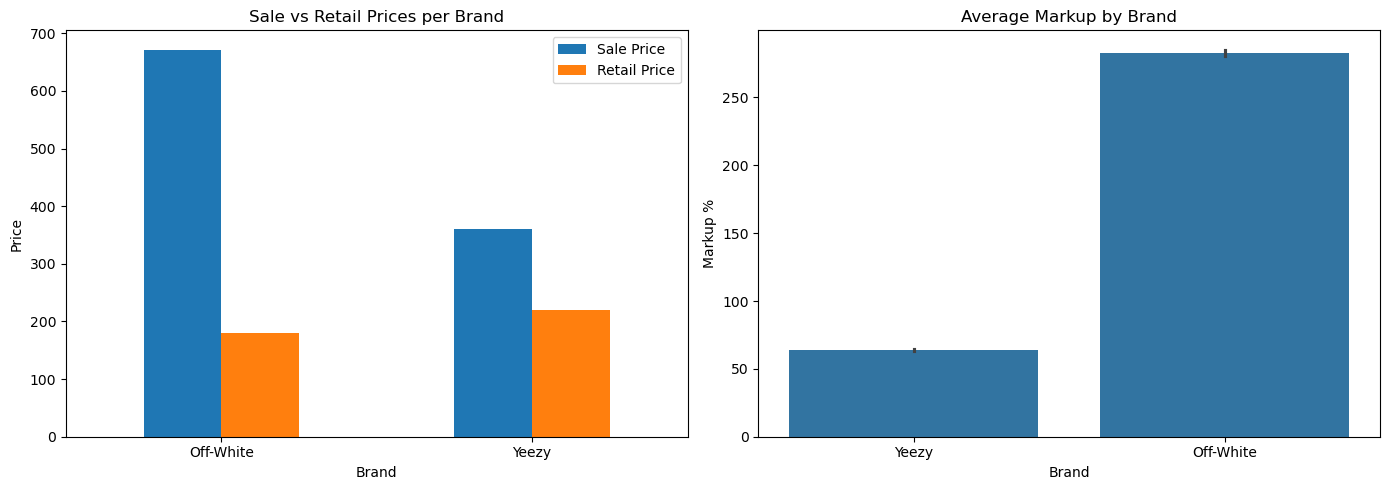

In [54]:
fig1, axes = plt.subplots(1, 2, figsize=(14, 5))

file.groupby("Brand")[["Sale Price", "Retail Price"]].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Sale vs Retail Prices per Brand")
axes[0].set_ylabel("Price")
axes[0].tick_params(axis="x", rotation=0)


sns.barplot(data=file, x="Brand", y="Markup %", ax=axes[1])
axes[1].set_title("Average Markup by Brand")
axes[1].set_ylabel("Markup %")


plt.tight_layout()
plt.show()

The first visualisation shows that Off-White has a much higher average sale price than Yeezy, even though its average retail price is lower. The markup chart also shows that Off-White has a clearly higher average markup percentage, meaning that Off-White sneakers generated a stronger resale premium in this dataset.

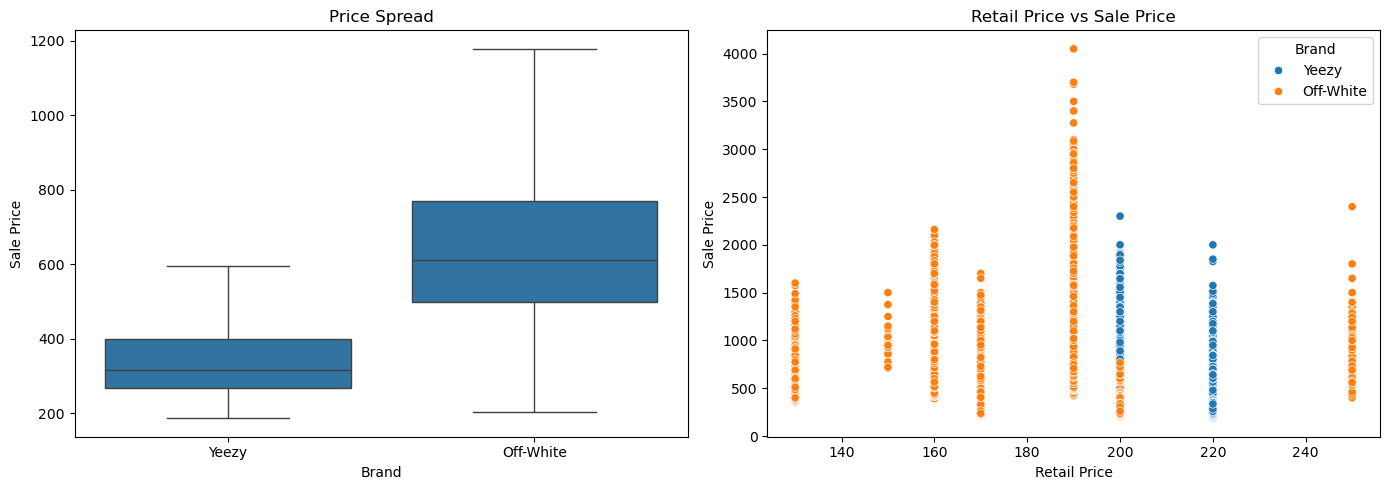

In [55]:
fig2, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=file, x="Brand", y="Sale Price", showfliers=False,ax=axes[0])
axes[0].set_title("Price Spread")

sns.scatterplot(data=file, x="Retail Price", y="Sale Price", hue="Brand", ax=axes[1])
axes[1].set_title("Retail Price vs Sale Price")

plt.tight_layout()
plt.show()

The boxplot shows that Off-White sale prices are generally higher and more widely spread than Yeezy sale prices. The scatterplot also shows that retail price alone does not explain resale value, as sneakers with similar retail prices can have very different sale prices.

## Quantitative Analysis

 I calculated brand-level summary statistics and performed a simple two-sample t-test. The t-test compares whether the average markup percentage differs between Yeezy and Off-White sneakers.

In [56]:
brand_summary = file.groupby("Brand")[["Sale Price", "Retail Price", "Markup %"]].mean().round(2)
display(brand_summary)

,Sale Price,Retail Price,Markup %
Brand,,,
Off-White,671.48,179.38,282.87
Yeezy,360.03,219.87,63.95


The summary table shows the average sale price, retail price, and markup percentage for each brand. 

In [57]:
from scipy import stats

yeezy_markup = file[file["Brand"] == "Yeezy"]["Markup %"]
off_white_markup = file[file["Brand"] == "Off-White"]["Markup %"]

yeezy_average = yeezy_markup.mean()
off_white_average = off_white_markup.mean()

print("Yeezy average markup:", round(yeezy_average, 2))
print("Off-White average markup:", round(off_white_average, 2))

test_result = stats.ttest_ind(yeezy_markup, off_white_markup, equal_var=False)

print("t-statistic:", round(test_result.statistic, 4))
print("p-value:", test_result.pvalue)


Yeezy average markup: 63.95
Off-White average markup: 282.87
t-statistic: -188.9376
p-value: 0.0


The t-test shows a clear difference in average markup between the two brands. Off-White has an average markup of 282.87%, while Yeezy has an average markup of 63.95%.

Since the p-value is below 0.05, the difference is statistically significant.

### Analysing data with an LLM

In [58]:
# analysing data with a LLM

sale_price_data = file.groupby("Brand")["Sale Price"].describe()
retail_price_data = file.groupby("Brand")["Retail Price"].describe()

In [59]:
# Loading API key

from google import genai
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.environ.get("API_KEY")

### Connecting to Gemini

We will prompt Gemini to summarize statistical findings from the quantitative analysis. Gemini receives the results from `.describe()` for both sale prices and retail prices by brand. The goal is to generate a short written interpretation of price spread, concentration, and highest values for Yeezy and Off-White.

In [60]:
from google import genai

gemini_client = genai.Client(api_key=api_key)

GEMINI_MODEL = "gemini-2.5-flash"

def ask_gemini(prompt):
    response = gemini_client.models.generate_content(
        model=GEMINI_MODEL,
        contents=prompt
    )
    return response.text

def analyse_shoes():
    prompt = f"""Give a very short summary of the price spreads and highest values 
    for Yeezy and Off-White, separately for sale price and retail price.
Say which brand is more spread out and which reaches higher top values.

Review:
{sale_price_data}
and Review:
{retail_price_data}"""

    return ask_gemini(prompt)

print(analyse_shoes())


Here's a summary:

*   **Sale Price Spreads & Highest Values:**
    *   **Off-White:** Sale prices range widely from \$203 to a high of \$4050.
    *   **Yeezy:** Sale prices range from \$186 to a high of \$2300.

*   **Retail Price Spreads & Highest Values:**
    *   **Off-White:** Retail prices are moderately spread from \$130 to a high of \$250.
    *   **Yeezy:** Retail prices are extremely concentrated, mostly around \$220, ranging from \$200 to \$220.

**Comparison:**
**Off-White** is significantly more spread out for both sale and retail prices. It also reaches considerably **higher top values** in both categories.


### Saving the data and saving the graphs

In [61]:
markup_data = file.groupby("Brand")[["Sale Price", "Retail Price", "Markup %"]].mean().reset_index().round(2)
sale_data = sale_price_data[["std", "min", "max"]].reset_index().round(2)
retail_data = retail_price_data[["std", "min", "max"]].reset_index().round(2)

# Results data
markup_data.to_csv("exports/markup_data.csv", index=False)
sale_data.to_csv("exports/sale_data.csv", index=False)
retail_data.to_csv("exports/retail_data.csv", index=False)

# Result figures
fig1.savefig("exports/Figure_1.png")
fig2.savefig("exports/Figure_2.png")

# Cleaned full dataset
file.to_csv("exports/cleaned_sneaker_data.csv", index=False)

### Conclusion

This project showed clear differences between Yeezy and Off-White sneakers in retail prices, resale prices, and markup percentages.

Off-White sneakers had much higher average sale prices than Yeezy and also showed a wider price spread. This means that Off-White resale prices were more variable and reached higher top values.

Yeezy prices were more concentrated, especially on the retail side, where most retail prices were close to 200 or 220.

The biggest difference was in markup. Off-White had a much higher average markup percentage than Yeezy, which shows that Off-White sneakers gained more value on the resale market relative to their retail price.

Overall, the results suggest that brand plays an important role in sneaker resale pricing in this dataset.

### AI Use Statement

In this project, AI coding assistance was used as little as possible. It was mainly used for spesific debugging parts, producing specific syntax, and brainstorming project ideas where i got stuck.

I want to specifically disclose that AI was used for generating the code structure that allow the placement of  two charts side by side, and for correctly transforming the Sale Price and Retail Price columns, which originally contained dollar symbols and commas.

AI was also used to improve the wording in markdown cells and to structure text blocks more clearly.